In [1]:
import yfinance as yf
stock = yf.Ticker("FB")
df = stock.history(period='max')

$$
r_t = \frac{S_t-S_{t-1}}{S_{t-1}}
$$

In [2]:
df['Daily_Return'] = df.Close.pct_change()

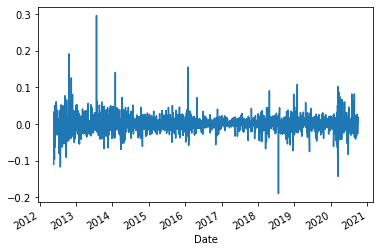

In [4]:
df.Daily_Return.plot()

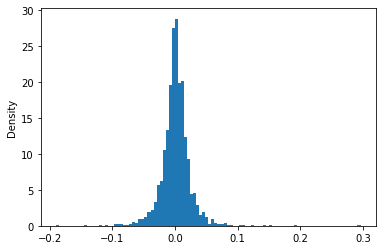

In [13]:
import matplotlib.pyplot as plt
df.Daily_Return.plot(kind='hist', bins=100, density=True)
plt.ylabel('Density')
plt.show()

/Users/sungchullee/.local/lib/python3.7/site-packages/numpy/lib/histograms.py:824: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/Users/sungchullee/.local/lib/python3.7/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


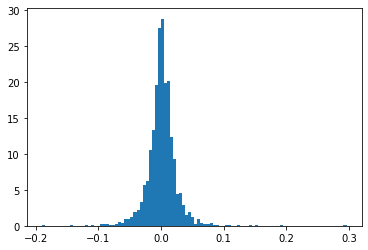

In [11]:
import matplotlib.pyplot as plt
plt.hist(df.Daily_Return, bins=100, density=True)
plt.show()

In [15]:
df[['Daily_Return']].describe()

,Daily_Return
count,2107.000000
mean,0.001185
std,0.023567
min,-0.189609
25%,-0.009161
50%,0.001077
75%,0.012076
max,0.296115


In [19]:
print(df[['Daily_Return']].describe().loc['mean','Daily_Return'])
print(df[['Daily_Return']].describe().loc['50%','Daily_Return'])
print(df[['Daily_Return']].describe().loc['std','Daily_Return'])

0.0011846317802768356
0.0010774203478529643
0.023567265088393376


In [24]:
x = df[['Daily_Return']].values[1:]
x.shape

(2107, 1)

$$
\bar{x} =\frac{\sum_{i=1}^n x_i}{n}
$$

In [31]:
x_bar = x.mean(axis=0)[0]

In [29]:
x.sum(axis=0)[0] / x.shape[0]

0.0011846317802768343

$$
\hat{\sigma}=\sqrt{\frac{\sum_{i=1}^n (x_i-\mu)^2}{n}}
$$
or
$$
\hat{\sigma}
=\sqrt{\frac{\sum_{i=1}^n (x_i-\bar{x})^2}{n-1}}
\approx \sqrt{\frac{\sum_{i=1}^n (x_i-\bar{x})^2}{n}}
$$

In [36]:
sigma = x.std(axis=0)[0]

In [30]:
x.std(axis=0, ddof=1)[0]

0.02356726508839339

In [34]:
import numpy as np
np.sqrt(((x - x_bar)**2).sum(axis=0)[0] / x.shape[0])

0.023561671813106737

In [35]:
import numpy as np
np.sqrt(((x - x_bar)**2).sum(axis=0)[0] / (x.shape[0]-1))

0.02356726508839339

/Users/sungchullee/.local/lib/python3.7/site-packages/numpy/lib/histograms.py:824: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/Users/sungchullee/.local/lib/python3.7/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


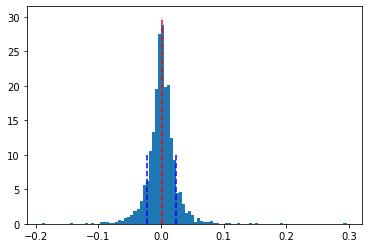

In [41]:
import matplotlib.pyplot as plt
plt.hist(df.Daily_Return, bins=100, density=True)
plt.plot([x_bar,x_bar],[0,30],'--r')
plt.plot([x_bar+sigma,x_bar+sigma],[0,10],'--b')
plt.plot([x_bar-sigma,x_bar-sigma],[0,10],'--b')
plt.show()

In [43]:
def give_me_daily_return(ticker):
    import yfinance as yf
    stock = yf.Ticker(ticker)
    df = stock.history(period='max')
    df[ticker] = df.Close.pct_change()
    return df[[ticker]].iloc[1:] 

In [44]:
df = give_me_daily_return('FB')
df

,FB
Date,
2012-05-21,-0.109861
2012-05-22,-0.089039
2012-05-23,0.032258
2012-05-24,0.032188
2012-05-25,-0.033909
...,...
2020-09-28,0.007849
2020-09-29,0.019352
2020-09-30,0.000420


In [45]:
dg = give_me_daily_return('SPY')
dg

,SPY
Date,
1993-02-01,0.007285
1993-02-02,0.001903
1993-02-03,0.010638
1993-02-04,0.004135
1993-02-05,-0.000749
...,...
2020-09-28,0.016609
2020-09-29,-0.005446
2020-09-30,0.007582


In [46]:
dh = df.join(dg, how='inner')
dh

,FB,SPY
Date,,
2012-05-21,-0.109861,0.017262
2012-05-22,-0.089039,0.001706
2012-05-23,0.032258,0.000538
2012-05-24,0.032188,0.001971
2012-05-25,-0.033909,-0.003219
...,...,...
2020-09-28,0.007849,0.016609
2020-09-29,0.019352,-0.005446
2020-09-30,0.000420,0.007582


$$
\rho = \frac{\sigma_{xy}}{\sigma_x\sigma_y}
=\frac{\frac{\sum_i^n(x_i-\bar{x})(y_i-\bar{y})}{n}}{\sqrt{\frac{\sum_{i=1}^n (x_i-\bar{x})^2}{n}}\sqrt{\frac{\sum_{i=1}^n (y_i-\bar{x})^2}{n}}}
$$

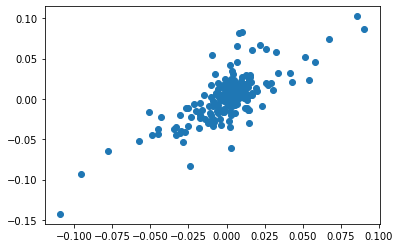

array([[1.        , 0.76940962],
       [0.76940962, 1.        ]])

In [62]:
plt.plot(dh.SPY[-200:], dh.FB[-200:], 'o')
plt.show()
np.corrcoef(dh.SPY[-200:], dh.FB[-200:])

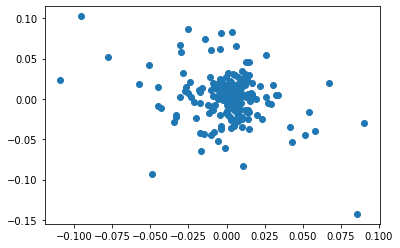

array([[ 1.        , -0.29512211],
       [-0.29512211,  1.        ]])

In [69]:
plt.plot(dh.SPY[-200:-1], dh.FB[-199:], 'o')
plt.show()
np.corrcoef(dh.SPY[-200:-1], dh.FB[-199:]) # -0.29512211

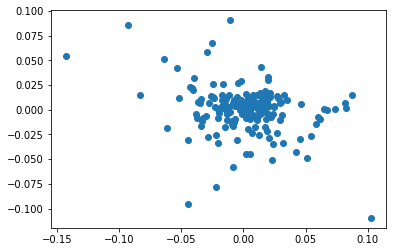

array([[ 1.       , -0.2931181],
       [-0.2931181,  1.       ]])

In [70]:
plt.plot(dh.FB[-200:-1], dh.SPY[-199:], 'o')
plt.show()
np.corrcoef(dh.FB[-200:-1], dh.SPY[-199:])

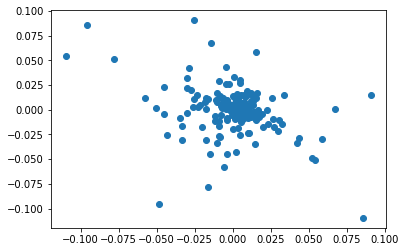

array([[ 1.        , -0.33633169],
       [-0.33633169,  1.        ]])

In [71]:
plt.plot(dh.SPY[-200:-1], dh.SPY[-199:], 'o')
plt.show()
np.corrcoef(dh.SPY[-200:-1], dh.SPY[-199:])

In [72]:
def give_me_std(series):
    return series.values.std()

In [73]:
give_me_std(dh.SPY)

0.010471826298047342

In [76]:
def give_me_covariance(series_1, series_2):
    x, y = series_1.values, series_2.values
    mu_x, mu_y = x.mean(), y.mean()
    cross_terms = (x-mu_x) * (y-mu_y)
    return cross_terms.mean()

In [77]:
give_me_covariance(dh.SPY, dh.FB)

0.00011678839450098565

In [80]:
def give_me_rho(series_1, series_2): 
    cov = give_me_covariance(series_1, series_2)
    std_1 = give_me_std(series_1)
    std_2 = give_me_std(series_2)
    return cov / (std_1*std_2)    

In [82]:
give_me_rho(dh.SPY[-200:], dh.FB[-200:])

0.7694096202371146

In [83]:
#np.corrcoef(dh.SPY[-200:-1], dh.FB[-199:]) # -0.29512211
give_me_rho(dh.SPY[-200:-1], dh.FB[-199:])

-0.29512211252763376